# 1 IMPORT DATASETS

In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
geolocation = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
order_payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
category_translation = pd.read_csv("../data/raw/product_category_name_translation.csv")

In [3]:
def print_columns(**dataframes):
    for name, df in dataframes.items():
        print(f"{name}:")
        print(df.columns.tolist())
        print()

columns = print_columns(
    customer=customers,
    geolocation=geolocation,
    order_items=order_items,
    order_payments=order_payments,
    order_reviews=order_reviews,
    orders=orders,
    products=products,
    sellers=sellers,
    category_name_translation=category_translation
)

print(columns)

customer:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

geolocation:
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

order_items:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

order_payments:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

order_reviews:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

orders:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

products:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_

---

### GET Basic Information

In [4]:
datasets = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "category_name_translation": category_translation
}

for name, data in datasets.items():

    print("\n" + "=" * 70)
    print(f"{name.upper()}")
    print("=" * 70)

    print("Shape:", data.shape)

    print("\nInfo:")
    data.info()

    print("\nDescribe:")
    print(data.describe(include="all").T)


CUSTOMERS
Shape: (99441, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

Describe:
                            count unique                               top  \
customer_id                 99441  99441  06b8999e2fba1a1fbc88172c00ba8bc7   
customer_unique_id          99441  96096  8d50f5eadf50201ccdcedfb9e2ac8455   
customer_zip_code_prefix  99441.0    NaN                               NaN   
customer_city               99441   4119                         sao paulo   
customer_state             

## E-Commerce Dataset — Key Insights (Summary)

## 1. Overview
| Table | Rows | Columns |
|---|---:|---:|
| Customers | 99,441 (96,096 unique) | 5 |
| Geolocation | 738,332 | 5 |
| Order Items | 112,650 | 7 |
| Order Payments | 103,886 | 5 |
| Order Reviews | 99,224 | 7 |
| Orders | 99,441 | 8 |
| Products | 32,951 | 9 |
| Sellers | 3,095 | 4 |
| Category Translation | 71 | 2 |

## 2. Customers
- 99,441 records but only 96,096 unique customers (`customer_unique_id` ≠ `customer_id`).
- Most frequent unique customer appears 17 times.
- Spread across 27 states, 4,119 cities. Top city/state: São Paulo (15,540 records) / SP (41,746 records).
- **Use `customer_unique_id`** for retention/repeat-purchase analysis.

## 3. Orders
- 99,441 orders, 8 statuses. `delivered` = 96,478 (~97%).
- Date range: 2016-09-04 → 2018-10-17. Median: ~2018-01-18.
- 5 timestamps available: purchase, approval, carrier delivery, customer delivery, estimated delivery.
- Missing: approved_at (160), delivered_carrier_date (1,783), delivered_customer_date (2,965).

## 4. Order Items
- 112,650 items / 98,666 unique orders. Max 21 items/order.
- 32,951 products, 3,095 sellers.
- **Price**: mean 120.65, median 74.99, max 6,735 (right-skewed).
- **Freight**: mean 19.99, median 16.26, max 409.68 (right-skewed).

## 5. Payments
- 103,886 records / 99,440 unique orders (max 29 per order).
- 5 payment types; `credit_card` = 73.9%.
- **Value**: mean 154.10, median 100.00, max 13,664.08.
- **Installments**: mean 2.85, median 1, max 24.

## 6. Products
- 32,951 products, 73 categories. Top category: `cama_mesa_banho` (3,029).
- Avg name length 48.48, description 771.50 chars, 2.19 photos.
- Avg dimensions: 2,276.47g / 30.82×16.94×23.20 cm.
- Missing: category/name/desc/photos (610), weight/L/H/W (2 each).

## 7. Reviews
- 99,224 records. Mean score 4.09, median 5 (range 1–5).
- Only 11.7% have a title, 41.3% have a message body → heavy missingness for NLP/sentiment work.
- Timestamps allow response-time analysis.

## 8. Sellers
- 3,095 sellers across 611 cities, 23 states.
- Top city: São Paulo (694 sellers). Top state: SP (1,849 sellers).
- Geographically concentrated around São Paulo.

## 9. Geolocation
- 738,332 records, 8,010 cities, 27 states.
- Same ZIP can map to multiple rows → **deduplicate/aggregate before joining** to avoid row multiplication.

## 10. Category Translation
- 71 PT categories translated to English; products table has 73 → **2 categories unmapped**, handle before using English names.

## 11. Relationships
-Customer → Orders → Order Items → Product → Category Translation
-→ Payments
-→ Reviews
-Order Items → Seller
-Customer/Seller → Geolocation

Main key: `order_id`.

## 12. Business Insight Areas
- **Customer**: repeat purchases, frequency, LTV, geography
- **Sales**: revenue, popularity, AOV, seller performance
- **Payments**: method mix, installments, multi-payment orders
- **Logistics**: delivery duration/delays, est. vs actual
- **Satisfaction**: review scores, sentiment, response time
- **Products**: category performance, dimensions, content quality

## 13. Data Quality Notes
1. `customer_id` vs `customer_unique_id` — different identity levels
2. `order_id` repeats in items & payments tables (not 1:1)
3. Review IDs not strictly 1:1 with orders
4. Missing values: products, delivery timestamps, review text
5. Geolocation needs dedup before joins
6. 2 categories missing from translation table
7. Price/payment distributions skewed by high-value outliers

## 14. Top Analytical Opportunities
- Sales performance (revenue, volume, AOV, category)
- Customer retention (via `customer_unique_id`)
- Delivery performance (actual vs. estimated)
- Seller performance (sales, delivery, reviews)
- Customer satisfaction drivers
- Product/category performance
- Geographic distribution analysis

## Final Takeaway
A **multi-table transactional dataset** linking Customer → Order → Product → Payment → Delivery → Review, enabling analysis across revenue, behavior, logistics, and satisfaction.

---

# 2 Cleaning 

### 2.1 Missing Values

In [5]:
missing_audit = []

for name, data in datasets.items():

    for column in data.columns:

        count = data[column].isna().sum()

        percentage = (
            data[column].isna().mean() * 100
        )

        missing_audit.append({
            "dataset": name,
            "column": column,
            "count": count,
            "percentage": percentage
        })


missing_audit = pd.DataFrame(
    missing_audit
)

print(missing_audit)

                      dataset                         column  count  \
0                   customers                    customer_id      0   
1                   customers             customer_unique_id      0   
2                   customers       customer_zip_code_prefix      0   
3                   customers                  customer_city      0   
4                   customers                 customer_state      0   
5                 geolocation    geolocation_zip_code_prefix      0   
6                 geolocation                geolocation_lat      0   
7                 geolocation                geolocation_lng      0   
8                 geolocation               geolocation_city      0   
9                 geolocation              geolocation_state      0   
10                order_items                       order_id      0   
11                order_items                  order_item_id      0   
12                order_items                     product_id      0   
13    

### 2.2 Exact Duplicates

In [6]:
duplicate_audit = []

for name, data in datasets.items():

    duplicate_count = data.duplicated().sum()

    duplicate_audit.append({
        "dataset": name,
        "exact_duplicates": duplicate_count
    })


duplicate_audit = pd.DataFrame(
    duplicate_audit
)

print(duplicate_audit)


                     dataset  exact_duplicates
0                  customers                 0
1                geolocation            261831
2                order_items                 0
3             order_payments                 0
4              order_reviews                 0
5                     orders                 0
6                   products                 0
7                    sellers                 0
8  category_name_translation                 0


### 2.3 Duplicate Order IDs

In [7]:
if "order_id" in orders.columns:

    duplicate_order_ids = (
        orders["order_id"]
        .duplicated()
        .sum()
    )

    print(
        "Duplicate Order IDs:",
        duplicate_order_ids
    )

Duplicate Order IDs: 0


### 2.4 Hidden Nulls

In [8]:
hidden_nulls = [
    "NA",
    "N/A",
    "Null",
    "null",
    "-",
    ""
]

hidden_null_audit = []

for name, data in datasets.items():

    for column in data.select_dtypes(
        include="object"
    ).columns:

        count = data[column].isin(
            hidden_nulls
        ).sum()

        if count > 0:

            hidden_null_audit.append({
                "dataset": name,
                "column": column,
                "hidden_null_count": count
            })


hidden_null_audit = pd.DataFrame(
    hidden_null_audit
)

print(hidden_null_audit)

         dataset                  column  hidden_null_count
0  order_reviews    review_comment_title                  1
1  order_reviews  review_comment_message                  3


### 2.5 Snake Case Columns

In [9]:
for name, data in datasets.items():

    data.columns = (
        data.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
    )

### 2.6 Strip Whitespace + Hidden Nulls

In [10]:
hidden_nulls = [
    "NA",
    "N/A",
    "Null",
    "null",
    "-"
]

for name, data in datasets.items():

    object_columns = data.select_dtypes(
        include="object"
    ).columns

    for column in object_columns:

        data[column] = (
            data[column]
            .str.strip()
        )

        data[column] = data[column].replace(
            hidden_nulls,
            np.nan
        )

### 2.7 Unify Casing

In [11]:
for name, data in datasets.items():

    object_columns = data.select_dtypes(
        include="object"
    ).columns

    for column in object_columns:

        data[column] = (
            data[column]
            .str.lower()
            .str.strip()
        )

### 2.8 Standardize Text Labels

In [12]:
mapping_log = []


def apply_mapping(
    data,
    column,
    mapping,
    dataset_name
):

    if column not in data.columns:
        return

    before = data[column].copy()

    data[column] = data[column].replace(
        mapping
    )

    for old_value, new_value in mapping.items():

        mapping_log.append({
            "dataset": dataset_name,
            "column": column,
            "old_value": old_value,
            "new_value": new_value
        })


# Example: Yes / No
yes_no_mapping = {
    "yes": "Yes",
    "y": "Yes",
    "no": "No",
    "n": "No"
}


# Example: Online / online
channel_mapping = {
    "online": "Online",
    "app": "App",
    "marketplace": "Marketplace"
}


# Apply only if these columns actually exist
for name, data in datasets.items():

    if "channel" in data.columns:

        apply_mapping(
            data,
            "channel",
            channel_mapping,
            name
        )


    if "returned" in data.columns:

        apply_mapping(
            data,
            "returned",
            yes_no_mapping,
            name
        )


mapping_log = pd.DataFrame(
    mapping_log
)

# 3. FIX DATA TYPES

### 3.1 Dates → datetime

In [13]:
date_columns = {

    "orders": [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ],

    "order_items": [
        "shipping_limit_date"
    ],

    "order_reviews": [
        "review_creation_date",
        "review_answer_timestamp"
    ]
}


for dataset_name, columns in date_columns.items():

    data = datasets[dataset_name]

    for column in columns:

        if column in data.columns:

            data[column] = pd.to_datetime(
                data[column],
                errors="coerce"
            )


### 3.2 Numerics → numeric

In [14]:
numeric_columns = {

    "customers": [
        "customer_zip_code_prefix"
    ],

    "geolocation": [
        "geolocation_zip_code_prefix",
        "geolocation_lat",
        "geolocation_lng"
    ],

    "order_items": [
        "order_item_id",
        "price",
        "freight_value"
    ],

    "order_payments": [
        "payment_sequential",
        "payment_installments",
        "payment_value"
    ],

    "order_reviews": [
        "review_score"
    ],

    "products": [
        "product_name_lenght",
        "product_description_lenght",
        "product_photos_qty",
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ],

    "sellers": [
        "seller_zip_code_prefix"
    ]
}


for dataset_name, columns in numeric_columns.items():

    data = datasets[dataset_name]

    for column in columns:

        if column in data.columns:

            data[column] = pd.to_numeric(
                data[column],
                errors="coerce"
            )

### 3.4 Categoricals → category

In [15]:
categorical_columns = {

    "customers": [
        "customer_city",
        "customer_state"
    ],

    "orders": [
        "order_status"
    ],

    "order_payments": [
        "payment_type"
    ],

    "products": [
        "product_category_name"
    ],

    "sellers": [
        "seller_city",
        "seller_state"
    ]
}


for dataset_name, columns in categorical_columns.items():

    data = datasets[dataset_name]

    for column in columns:

        if column in data.columns:

            data[column] = data[column].astype(
                "category"
            )

# 4. BUSINESS RULE VALIDATION

### 4.1 Price > 0

In [16]:
validation_results = []

invalid_prices = (
    order_items["price"] <= 0
).sum()

validation_results.append({
    "rule": "price > 0",
    "invalid_count": invalid_prices
})

### 4.2 Freight >= 0

In [17]:
invalid_freight = (
    order_items["freight_value"] < 0
).sum()

validation_results.append({
    "rule": "freight_value >= 0",
    "invalid_count": invalid_freight
})


### 4.3 Payment > 0

In [18]:
invalid_payment = (
    order_payments["payment_value"] <= 0
).sum()

validation_results.append({
    "rule": "payment_value > 0",
    "invalid_count": invalid_payment
})

### 4.4 Review score: 1–5

In [19]:
invalid_rating = (
    ~order_reviews["review_score"].between(
        1,
        5
    )
).sum()

validation_results.append({
    "rule": "review_score between 1 and 5",
    "invalid_count": invalid_rating
})

### 4.5 Product dimensions > 0

In [20]:
for column in [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]:

    invalid_count = (
        products[column] <= 0
    ).sum()

    validation_results.append({
        "rule": f"{column} > 0",
        "invalid_count": invalid_count
    })

### 4.7 Delivery date validation

In [21]:
invalid_delivery_dates = (
    orders["order_delivered_customer_date"]
    <
    orders["order_purchase_timestamp"]
).sum()

validation_results.append({
    "rule": "delivery_date >= purchase_date",
    "invalid_count": invalid_delivery_dates
})


validation_results = pd.DataFrame(
    validation_results
)

print(validation_results)

                             rule  invalid_count
0                       price > 0              0
1              freight_value >= 0              0
2               payment_value > 0              9
3    review_score between 1 and 5              0
4            product_weight_g > 0              4
5           product_length_cm > 0              0
6           product_height_cm > 0              0
7            product_width_cm > 0              0
8  delivery_date >= purchase_date              0


# 5 Visualization

In [22]:
DATA_DIR = "../data"
OUT_DIR = "../visuals"
os.makedirs(OUT_DIR, exist_ok=True)

### 5.1 Order Status Distribution

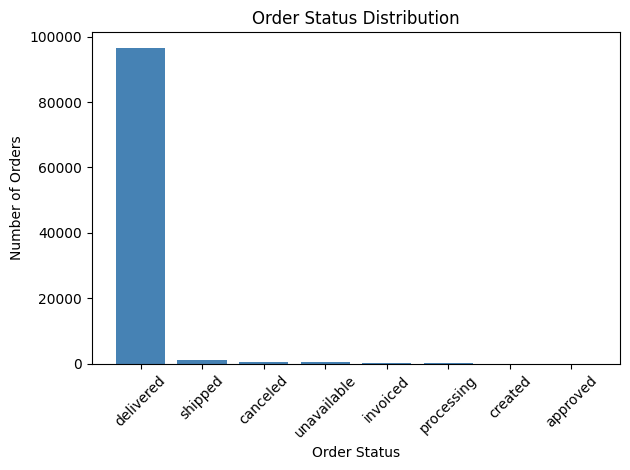

In [23]:
status_counts = orders["order_status"].value_counts()

plt.bar(status_counts.index, status_counts.values, color="steelblue")
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "01_order_status_distribution.png"))
plt.show()

### 5.2 Review Score Distribution

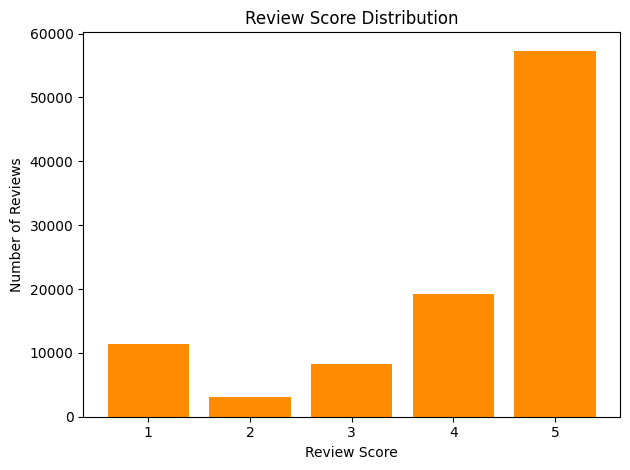

In [24]:
review_counts = order_reviews["review_score"].value_counts().sort_index()

plt.bar(review_counts.index.astype(str), review_counts.values, color="darkorange")
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "02_review_score_distribution.png"))
plt.show()

### 5.3 Monthly Orders Trend

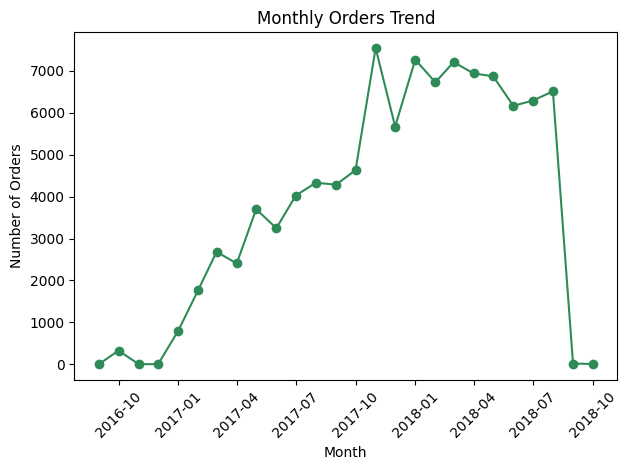

In [25]:
orders_by_month = (
    orders.dropna(subset=["order_purchase_timestamp"])
    .set_index("order_purchase_timestamp")
    .resample("MS")
    .size()
)

plt.plot(orders_by_month.index, orders_by_month.values, marker="o", color="seagreen")
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "03_monthly_orders_trend.png"))
plt.show()

### 5.4 Top 10 States by Number of Customers

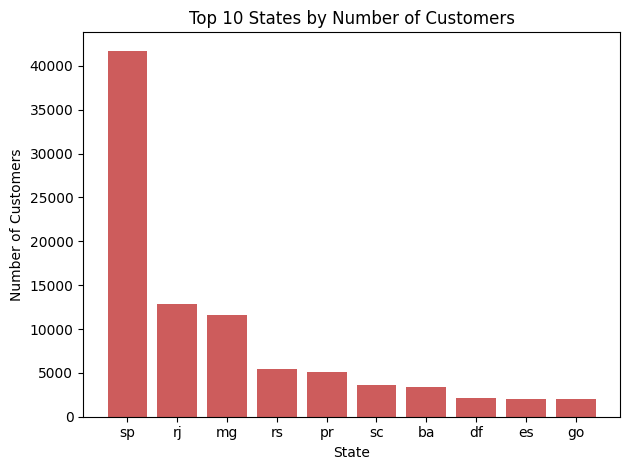

In [26]:
top_states = customers["customer_state"].value_counts().head(10)

plt.bar(top_states.index, top_states.values, color="indianred")
plt.title("Top 10 States by Number of Customers")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "04_top10_states_customers.png"))
plt.show()

### 5.5 Top 10 Product Categories by Items Sold

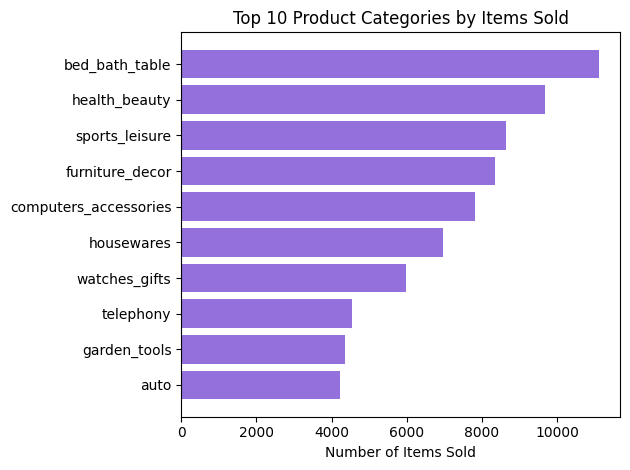

In [27]:
items_products = order_items.merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
items_products = items_products.merge(category_translation, on="product_category_name", how="left")

top_categories = items_products["product_category_name_english"].value_counts().head(10)

plt.barh(top_categories.index[::-1], top_categories.values[::-1], color="mediumpurple")
plt.title("Top 10 Product Categories by Items Sold")
plt.xlabel("Number of Items Sold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "05_top10_categories.png"))
plt.show()

### 5.6 Payment Type Distribution

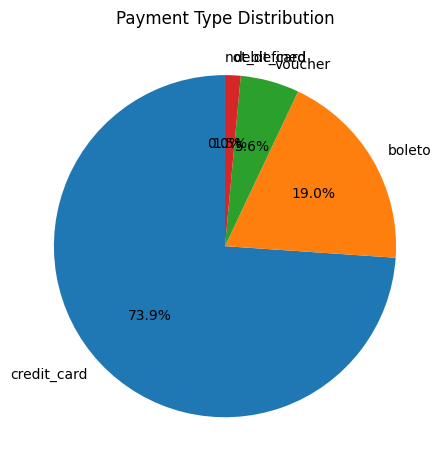

In [28]:
payment_type_counts = order_payments["payment_type"].value_counts()

plt.pie(payment_type_counts.values, labels=payment_type_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Payment Type Distribution")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "06_payment_type_distribution.png"))
plt.show()

### 5.7 Payment Installments Distribution

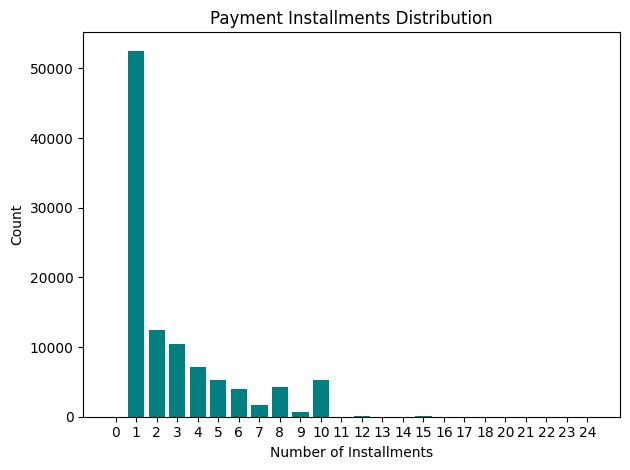

In [29]:
installments_counts = order_payments["payment_installments"].value_counts().sort_index()

plt.bar(installments_counts.index.astype(str), installments_counts.values, color="teal")
plt.title("Payment Installments Distribution")
plt.xlabel("Number of Installments")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "07_payment_installments_distribution.png"))
plt.show()

## 5.8 Product Price Distribution

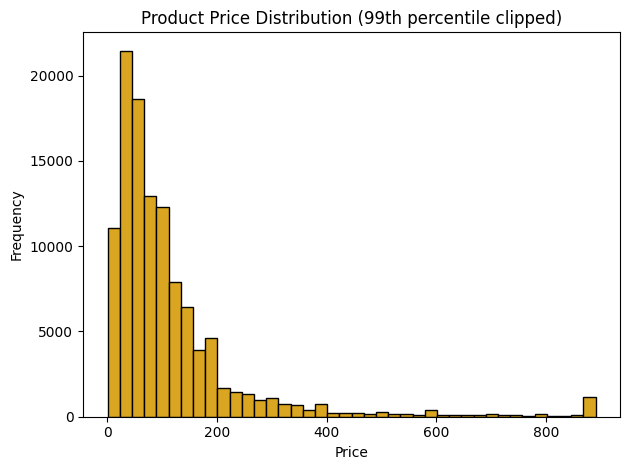

In [30]:
price_clipped = order_items["price"].clip(upper=order_items["price"].quantile(0.99))

plt.hist(price_clipped, bins=40, color="goldenrod", edgecolor="black")
plt.title("Product Price Distribution (99th percentile clipped)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "08_price_distribution.png"))
plt.show()

### 5.9 Price vs Freight Value

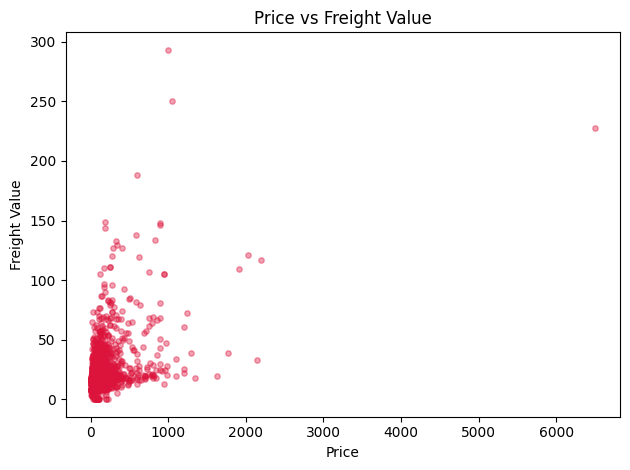

In [31]:
sample = order_items.sample(min(3000, len(order_items)), random_state=1)

plt.scatter(sample["price"], sample["freight_value"], alpha=0.4, color="crimson", s=15)
plt.title("Price vs Freight Value")
plt.xlabel("Price")
plt.ylabel("Freight Value")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "09_price_vs_freight.png"))
plt.show()

### 5.10 Delivery Time Distribution (Days)

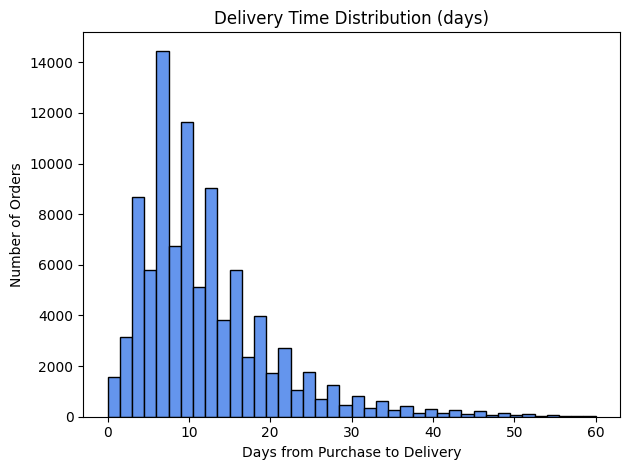

In [32]:
delivery_days = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.days
delivery_days = delivery_days.dropna()
delivery_days = delivery_days[(delivery_days >= 0) & (delivery_days <= 60)]

plt.hist(delivery_days, bins=40, color="cornflowerblue", edgecolor="black")
plt.title("Delivery Time Distribution (days)")
plt.xlabel("Days from Purchase to Delivery")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "10_delivery_time_distribution.png"))
plt.show()

### 5.11 Top 10 Sellers by Number of Order Items

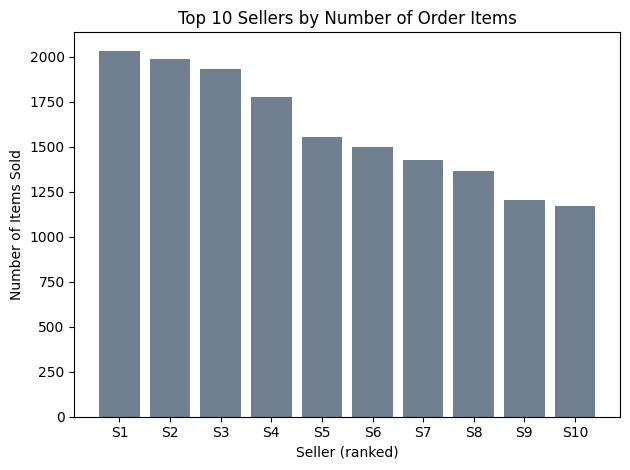

In [33]:
top_sellers = order_items["seller_id"].value_counts().head(10)

plt.bar(range(len(top_sellers)), top_sellers.values, color="slategray")
plt.title("Top 10 Sellers by Number of Order Items")
plt.xlabel("Seller (ranked)")
plt.ylabel("Number of Items Sold")
plt.xticks(range(len(top_sellers)), [f"S{i+1}" for i in range(len(top_sellers))])
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "11_top10_sellers.png"))
plt.show()

### 12. Average Review Score - Top 10 Categories

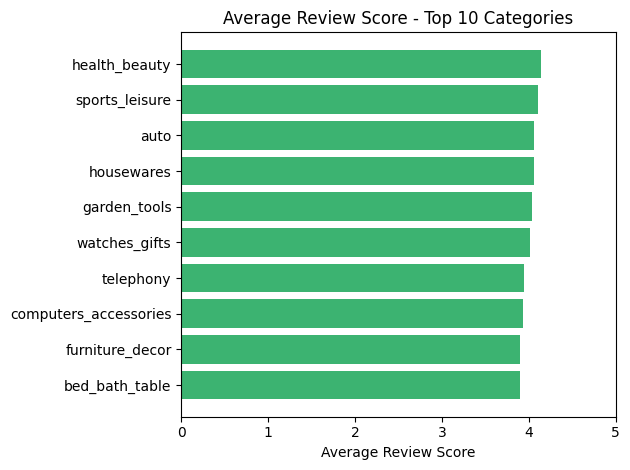

In [34]:
reviews_orders = order_reviews.merge(orders[["order_id"]], on="order_id", how="inner")
reviews_items = reviews_orders.merge(order_items[["order_id", "product_id"]], on="order_id", how="left")
reviews_items = reviews_items.merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
reviews_items = reviews_items.merge(category_translation, on="product_category_name", how="left")

top10_cats = items_products["product_category_name_english"].value_counts().head(10).index
avg_score = (
    reviews_items[reviews_items["product_category_name_english"].isin(top10_cats)]
    .groupby("product_category_name_english")["review_score"]
    .mean()
    .sort_values()
)

plt.barh(avg_score.index, avg_score.values, color="mediumseagreen")
plt.title("Average Review Score - Top 10 Categories")
plt.xlabel("Average Review Score")
plt.xlim(0, 5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "12_avg_review_score_top10_categories.png"))
plt.show()

---

# 6 Feature Engineering

### 6.1 BUILD MODELING DATASET

In [35]:
df = (
    orders
    .merge(
        customers,
        on="customer_id",
        how="left"
    )
    .merge(
        order_items,
        on="order_id",
        how="left"
    )
    .merge(
        products,
        on="product_id",
        how="left"
    )
    .merge(
        category_translation,
        on="product_category_name",
        how="left"
    )
)

In [36]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english'],
      dtype='object')

In [37]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

### 6.1 aggregate order-level totals (price + freight)

In [38]:
order_value = (
    df.groupby(['order_id', 'customer_unique_id', 'order_purchase_timestamp'])
      .agg(order_total=('price', 'sum'),
           order_freight=('freight_value', 'sum'))
      .reset_index()
)
order_value['order_total_with_freight'] = order_value['order_total'] + order_value['order_freight']

### 6.2 core RFM metrics

In [39]:
rfm = order_value.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('order_total_with_freight', 'sum')
).reset_index()

rfm['avg_order_value'] = rfm['monetary'] / rfm['frequency']

### 6.3 preferred category (most frequent category per customer)

In [40]:
preferred_category = (
    df.groupby('customer_unique_id')['product_category_name_english']
      .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
      .reset_index()
      .rename(columns={'product_category_name_english': 'preferred_category'})
)

### 6.4 area (customer state and city)

In [41]:
area = (
    df.groupby('customer_unique_id')
      .agg(customer_state=('customer_state', 'first'),
           customer_city=('customer_city', 'first'))
      .reset_index()
)


### 6.5 return rate proxy (based on order_status)

In [42]:
order_status_flags = df.groupby(['customer_unique_id', 'order_id'])['order_status'].first().reset_index()

return_rate = (
    order_status_flags.groupby('customer_unique_id')
      .agg(
          total_orders=('order_id', 'nunique'),
          problematic_orders=('order_status', lambda x: x.isin(['canceled', 'unavailable']).sum())
      )
      .reset_index()
)
return_rate['return_rate'] = return_rate['problematic_orders'] / return_rate['total_orders']

### 6.6 preferred channel (payment_type) & avg installments

In [43]:
order_customer_map = df[['order_id', 'customer_unique_id']].drop_duplicates()

payments_with_customer = order_payments.merge(order_customer_map, on='order_id', how='left')

preferred_channel = (
    payments_with_customer.groupby('customer_unique_id')['payment_type']
      .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
      .reset_index()
      .rename(columns={'payment_type': 'preferred_channel'})
)

avg_installments = (
    payments_with_customer.groupby('customer_unique_id')['payment_installments']
      .mean()
      .reset_index()
      .rename(columns={'payment_installments': 'avg_installments'})
)

### 6.7 average review score

In [44]:
reviews_with_customer = order_reviews.merge(order_customer_map, on='order_id', how='left')

avg_review_score = (
    reviews_with_customer.groupby('customer_unique_id')['review_score']
      .mean()
      .reset_index()
      .rename(columns={'review_score': 'avg_review_score'})
)

### 6.8 delivery timing features

In [45]:
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

# delivery_delay: actual delivery date minus estimated delivery date (in days)
# positive = delivered late, negative = delivered early, NaN = not delivered yet
df['delivery_delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

# avg_delivery_time: actual delivery date minus purchase date (in days)
df['delivery_time_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

delivery_features = df.groupby('customer_unique_id').agg(
    delivery_delay=('delivery_delay_days', 'mean'),
    avg_delivery_time=('delivery_time_days', 'mean')
).reset_index()

### 6.9 avg freight ratio (freight_value / price)

In [46]:
df['freight_ratio'] = df['freight_value'] / df['price'].replace(0, pd.NA)

avg_freight_ratio = (
    df.groupby('customer_unique_id')['freight_ratio']
      .mean()
      .reset_index()
      .rename(columns={'freight_ratio': 'avg_freight_ratio'})
)

### 6.10 category diversity (number of distinct categories purchased) 

In [47]:
category_diversity = (
    df.groupby('customer_unique_id')['product_category_name_english']
      .nunique()
      .reset_index()
      .rename(columns={'product_category_name_english': 'category_diversity'})
)

### 6.11 tenure (days between first and last order)

In [48]:
tenure = (
    df.groupby('customer_unique_id')['order_purchase_timestamp']
      .agg(first_order='min', last_order='max')
      .reset_index()
)
tenure['tenure_days'] = (tenure['last_order'] - tenure['first_order']).dt.days

### 6.12 merge everything into rfm

In [49]:
rfm = (
    rfm.merge(preferred_category, on='customer_unique_id', how='left')
       .merge(area, on='customer_unique_id', how='left')
       .merge(return_rate[['customer_unique_id', 'return_rate']], on='customer_unique_id', how='left')
       .merge(preferred_channel, on='customer_unique_id', how='left')
       .merge(avg_installments, on='customer_unique_id', how='left')
       .merge(avg_review_score, on='customer_unique_id', how='left')
       .merge(delivery_features, on='customer_unique_id', how='left')
       .merge(avg_freight_ratio, on='customer_unique_id', how='left')
       .merge(category_diversity, on='customer_unique_id', how='left')
       .merge(tenure[['customer_unique_id', 'tenure_days']], on='customer_unique_id', how='left')
)

print(rfm.head())
print(rfm.columns.tolist())

                 customer_unique_id  recency  frequency  monetary  \
0  0000366f3b9a7992bf8c76cfdf3221e2      161          1    141.90   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      164          1     27.19   
2  0000f46a3911fa3c0805444483337064      586          1     86.22   
3  0000f6ccb0745a6a4b88665a16c9f078      370          1     43.62   
4  0004aac84e0df4da2b147fca70cf8255      337          1    196.89   

   avg_order_value preferred_category customer_state customer_city  \
0           141.90     bed_bath_table             sp       cajamar   
1            27.19      health_beauty             sp        osasco   
2            86.22         stationery             sc      sao jose   
3            43.62          telephony             pa         belem   
4           196.89          telephony             sp      sorocaba   

   return_rate preferred_channel  avg_installments  avg_review_score  \
0          0.0       credit_card               8.0               5.0   
1          0.0      

In [50]:
rfm

,customer_unique_id,recency,frequency,monetary,avg_order_value,preferred_category,customer_state,customer_city,return_rate,preferred_channel,avg_installments,avg_review_score,delivery_delay,avg_delivery_time,avg_freight_ratio,category_diversity,tenure_days
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,141.90,bed_bath_table,sp,cajamar,0.0,credit_card,8.0,5.0,-5.0,6.0,0.092379,1,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,27.19,health_beauty,sp,osasco,0.0,credit_card,1.0,4.0,-5.0,3.0,0.438624,1,0
2,0000f46a3911fa3c0805444483337064,586,1,86.22,86.22,stationery,sc,sao jose,0.0,credit_card,8.0,3.0,-2.0,25.0,0.249565,1,0
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,43.62,telephony,pa,belem,0.0,credit_card,4.0,4.0,-12.0,20.0,0.678338,1,0
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,196.89,telephony,sp,sorocaba,0.0,credit_card,6.0,5.0,-8.0,13.0,0.093833,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,496,1,2067.42,2067.42,health_beauty,pe,sanharo,0.0,credit_card,10.0,5.0,-27.0,27.0,0.320939,1,0
96092,fffea47cd6d3cc0a88bd621562a9d061,311,1,84.58,84.58,baby,ba,feira de santana,0.0,credit_card,1.0,4.0,-3.0,30.0,0.303437,1,0
96093,ffff371b4d645b6ecea244b27531430a,618,1,112.46,112.46,auto,mt,sinop,0.0,credit_card,1.0,5.0,-30.0,14.0,0.250945,1,0
96094,ffff5962728ec6157033ef9805bacc48,169,1,133.69,133.69,watches_gifts,es,bom jesus do norte,0.0,credit_card,5.0,5.0,-14.0,11.0,0.162522,1,0


In [51]:
rfm.columns

Index(['customer_unique_id', 'recency', 'frequency', 'monetary',
       'avg_order_value', 'preferred_category', 'customer_state',
       'customer_city', 'return_rate', 'preferred_channel', 'avg_installments',
       'avg_review_score', 'delivery_delay', 'avg_delivery_time',
       'avg_freight_ratio', 'category_diversity', 'tenure_days'],
      dtype='object')

In [52]:
# Save the rfm DataFrame to a CSV file
rfm.to_csv("../data/rfm_final.csv", index=False)
print("Saved:", rfm.shape)

Saved: (96096, 17)


---

# 7 Final Feature Visuals

### 7.1 Correlation Heatmap of Numeric Features

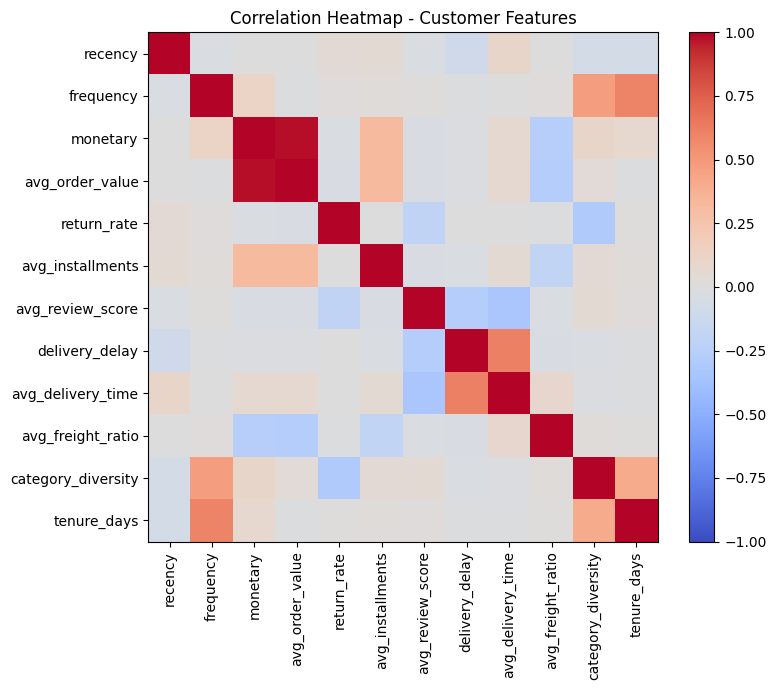

In [53]:
numeric_cols = [
    "recency", "frequency", "monetary", "avg_order_value", "return_rate",
    "avg_installments", "avg_review_score", "delivery_delay",
    "avg_delivery_time", "avg_freight_ratio", "category_diversity", "tenure_days"
]

corr = rfm[numeric_cols].corr()

plt.figure(figsize=(9, 7))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Heatmap - Customer Features")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "13_correlation_heatmap.png"))
plt.show()

### 7.2 Correlation Heatmap of Numeric Features

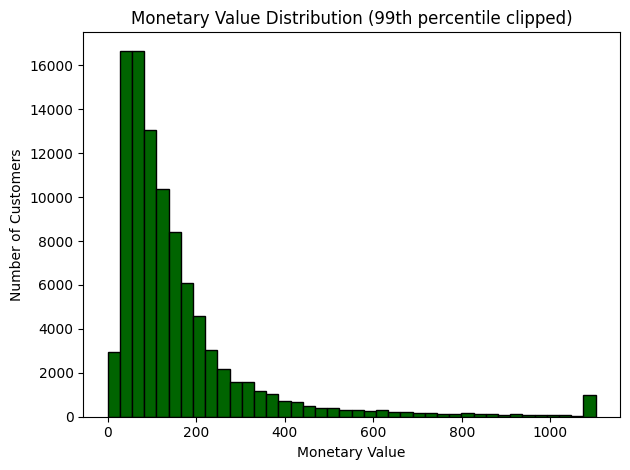

In [54]:
monetary_clipped = rfm["monetary"].clip(upper=rfm["monetary"].quantile(0.99))

plt.hist(monetary_clipped, bins=40, color="darkgreen", edgecolor="black")
plt.title("Monetary Value Distribution (99th percentile clipped)")
plt.xlabel("Monetary Value")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "14_monetary_distribution.png"))
plt.show()

### 7.3 Recency vs Frequency (colored by Monetary)

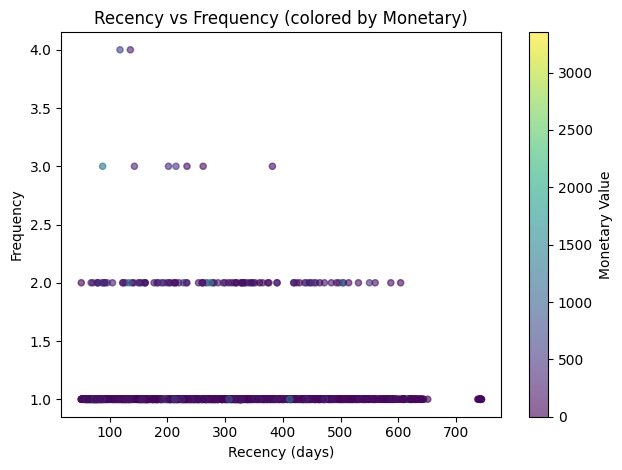

In [55]:
sample = rfm.sample(min(3000, len(rfm)), random_state=1)

sc = plt.scatter(sample["recency"], sample["frequency"], c=sample["monetary"],
                  cmap="viridis", alpha=0.6, s=20)
plt.colorbar(sc, label="Monetary Value")
plt.title("Recency vs Frequency (colored by Monetary)")
plt.xlabel("Recency (days)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "15_recency_vs_frequency.png"))
plt.show()

### 7.4 Top 10 States by Number of Customers

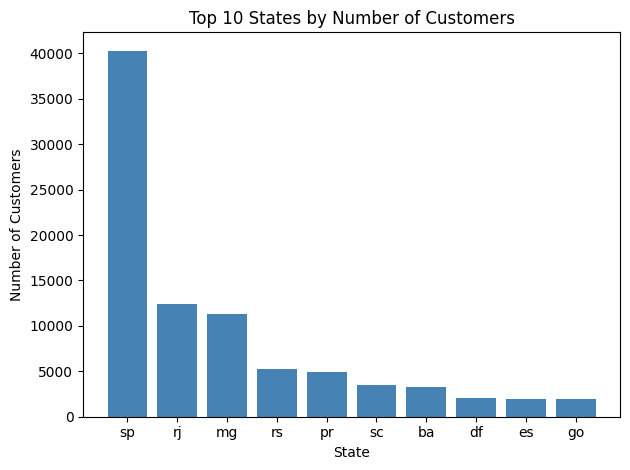

In [56]:
top_states = rfm["customer_state"].value_counts().head(10)

plt.bar(top_states.index, top_states.values, color="steelblue")
plt.title("Top 10 States by Number of Customers")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "16_top10_states_customer_features.png"))
plt.show()

### 7.5 Preferred Category Distribution (Top 10)

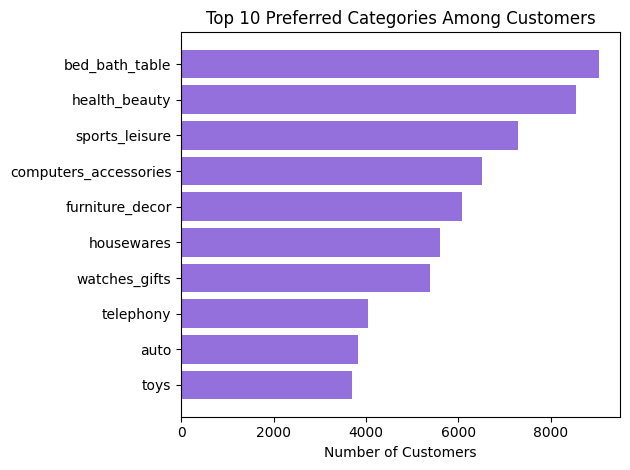

In [57]:
top_pref_categories = rfm ["preferred_category"].value_counts().head(10)

plt.barh(top_pref_categories.index[::-1], top_pref_categories.values[::-1], color="mediumpurple")
plt.title("Top 10 Preferred Categories Among Customers")
plt.xlabel("Number of Customers")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "17_preferred_category_distribution.png"))
plt.show()

---

# 8 Modeling

### 8.1 PREPROCESSING: StandardScaler + log-transform for skewed features

In [58]:
cluster_df = rfm.copy()

# Log-transform skewed monetary/count-type features (log1p handles zeros safely)
skewed_cols = ["monetary", "avg_order_value", "frequency", "tenure_days"]
for col in skewed_cols:
    cluster_df[f"{col}_log"] = np.log1p(cluster_df[col].clip(lower=0))

# delivery_delay / avg_delivery_time can be NaN for undelivered orders —
# fill with the column median so those customers aren't dropped
for col in ["delivery_delay", "avg_delivery_time", "avg_freight_ratio"]:
    cluster_df[col] = cluster_df[col].fillna(cluster_df[col].median())

features_for_scaling = [
    "recency",
    "monetary_log",
    "frequency_log",
    "avg_order_value_log",
    "return_rate",
    "avg_installments",
    "avg_review_score",
    "delivery_delay",
    "avg_delivery_time",
    "avg_freight_ratio",
    "category_diversity",
]

X = cluster_df[features_for_scaling].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### 8.2 Determine the optimal number of clusters (K) for KMeans using the elbow method and silhouette score

In [59]:
k_range = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    )

# --- Elbow plot ---
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker="o")
plt.title("Elbow Method — Inertia vs K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)
plt.savefig("../visuals/elbow_plot.png", dpi=150, bbox_inches="tight")
plt.close()

# --- Silhouette plot ---
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouette_scores, marker="o", color="darkorange")
plt.title("Silhouette Score vs K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(alpha=0.3)
plt.savefig("../visuals/silhouette_plot.png", dpi=150, bbox_inches="tight")
plt.close()

best_k = list(k_range)[int(np.argmax(silhouette_scores))]
print(f"\nBest K by silhouette score: {best_k}")
print("Inertias:", dict(zip(k_range, inertias)))
print("Silhouette scores:", dict(zip(k_range, silhouette_scores)))


Best K by silhouette score: 5
Inertias: {2: 916020.470724281, 3: 797454.5612405472, 4: 690877.1070130582, 5: 610089.192192682, 6: 557955.2621865801, 7: 518181.81173559924, 8: 486200.81153688254}
Silhouette scores: {2: 0.15865577298673988, 3: 0.18467637088680589, 4: 0.18788813918067393, 5: 0.19388222776503083, 6: 0.17914980638529432, 7: 0.16585191633123136, 8: 0.17199293162331797}


### 8.3 Fit three clustering models on the scaled data — KMeans (K=5), DBSCAN, and Agglomerative (Hierarchical) clustering on a 5,000-point sample

In [60]:
best_k = 5

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)
print("KMeans done")

dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)
print("DBSCAN done")

np.random.seed(42)
sample_size = 5000
sample_idx = np.random.choice(X_scaled.shape[0], size=sample_size, replace=False)
X_sample = X_scaled[sample_idx]

hier = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
hier_labels_sample = hier.fit_predict(X_sample)
print("Hierarchical done")

KMeans done
DBSCAN done
Hierarchical done


### 8.4 EVALUATE ALL THREE MODELS

In [61]:
def evaluate_clustering(name, X, labels):
    unique_labels = set(labels)
    unique_labels.discard(-1)
    if len(unique_labels) < 2:
        print(f"{name}: not enough clusters to evaluate.")
        return None
    mask = labels != -1
    sil = silhouette_score(X[mask], labels[mask], sample_size=5000, random_state=42)
    db = davies_bouldin_score(X[mask], labels[mask])
    sizes = pd.Series(labels[mask]).value_counts(normalize=True).sort_index()
    print(f"\n--- {name} ---")
    print(f"Clusters found: {sorted(unique_labels)}")
    print(f"Silhouette Score: {sil:.3f}")
    print(f"Davies-Bouldin Index: {db:.3f} (lower is better)")
    print("Segment size balance (proportion):")
    print(sizes)
    return {"name": name, "silhouette": sil, "davies_bouldin": db, "sizes": sizes}

In [62]:
result_kmeans = evaluate_clustering("KMeans", X_scaled, kmeans_labels)
print("kmean done")
result_dbscan = evaluate_clustering("DBSCAN", X_scaled, dbscan_labels)
print("DBSCAN done")
result_hier = evaluate_clustering("Hierarchical", X_sample, hier_labels_sample)
print("Hierarchical done")


--- KMeans ---
Clusters found: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)]
Silhouette Score: 0.194
Davies-Bouldin Index: 1.299 (lower is better)
Segment size balance (proportion):
0    0.475139
1    0.410621
2    0.071658
3    0.031083
4    0.011499
Name: proportion, dtype: float64
kmean done

--- DBSCAN ---
Clusters found: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Silhouette Score: 0.390
Davies-Bouldin Index: 0.809 (lower is better)
Segment size balance (proportion):
0    0.944608
1    0.005446
2    0.012518
3    0.013510
4    0.006966
5    0.012159
6    0.003926
7    0.000486
8    0.000232
9    0.000148
Name: proportion, dtype: float64
DBSCAN done

--- Hierarchical ---
Clusters found: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Silhouette Score: 0.244
Davies-Bouldin Index: 1.244 (lower is better)
Segment size balance (proportion):
0    0.1756
1    0.78

### 8.5 FINAL SEGMENT ASSIGNMENT

In [63]:
rfm["segment"] = kmeans_labels

### 8.6 SEGMENT PROFILING

In [64]:
profile = rfm.groupby("segment").agg(
    customers=("customer_unique_id", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    avg_order_value=("avg_order_value", "mean"),
    avg_return_rate=("return_rate", "mean"),
    avg_review_score=("avg_review_score", "mean"),
    avg_delivery_delay=("delivery_delay", "mean"),
    avg_delivery_time=("avg_delivery_time", "mean"),
    avg_freight_ratio=("avg_freight_ratio", "mean"),
    avg_category_diversity=("category_diversity", "mean"),
    avg_tenure_days=("tenure_days", "mean"),
    total_revenue=("monetary", "sum"),
).reset_index()

profile["pct_of_customers"] = 100 * profile["customers"] / profile["customers"].sum()
profile["pct_of_revenue"] = 100 * profile["total_revenue"] / profile["total_revenue"].sum()

top_category = rfm.groupby("segment")["preferred_category"].agg(lambda x: x.mode().iloc[0])
top_channel = rfm.groupby("segment")["preferred_channel"].agg(lambda x: x.mode().iloc[0])
profile["top_category"] = profile["segment"].map(top_category)
profile["top_channel"] = profile["segment"].map(top_channel)

print("\n=== SEGMENT PROFILE TABLE ===")
print(profile.round(2))
profile.to_csv("../data/segment_profile_table.csv", index=False)

# --- Segment size chart ---
plt.figure(figsize=(8, 5))
plt.bar(profile["segment"].astype(str), profile["pct_of_customers"], color="steelblue")
plt.title("Segment Size (% of Customers)")
plt.xlabel("Segment")
plt.ylabel("% of Customers")
plt.grid(alpha=0.3, axis="y")
plt.savefig("../visuals/segment_size_chart.png", dpi=150, bbox_inches="tight")
plt.close()



=== SEGMENT PROFILE TABLE ===
   segment  customers  avg_recency  avg_frequency  avg_monetary  \
0        0      45659       287.01           1.00         66.86   
1        1      39459       290.88           1.00        267.95   
2        2       6886       285.43           1.00        174.19   
3        3       2987       268.70           2.11        308.82   
4        4       1105       358.01           1.01         86.85   

   avg_order_value  avg_return_rate  avg_review_score  avg_delivery_delay  \
0            66.85             0.00              4.33              -12.81   
1           267.93             0.00              4.24              -14.20   
2           174.07             0.00              1.89                8.01   
3           146.53             0.02              4.12              -12.76   
4            86.85             1.00              1.59              -27.83   

   avg_delivery_time  avg_freight_ratio  avg_category_diversity  \
0               9.81               0

### 8.7 NAME THE SEGMENTS (heuristic rules — review and adjust after seeing your actual numbers)

In [67]:
def name_segment(row):

    high_monetary = row["avg_monetary"] > profile["avg_monetary"].median()
    good_review = row["avg_review_score"] >= 4.0
    bad_review = row["avg_review_score"] < 3.0
    late_delivery = row["avg_delivery_delay"] > 0     
    high_return = row["avg_return_rate"] > 0.10        
    repeat_customer = row["avg_frequency"] > 1.5        

    if repeat_customer and high_monetary and good_review:
        return "High-Value Loyalists"

    if high_monetary and good_review and not late_delivery:
        return "High-Value One-Time Buyers"

    if late_delivery and bad_review:
        return "Delivery-Frustrated"

    if high_return:
        return "Bargain Hunters / High-Return"

    if not high_monetary and good_review:
        return "Low-Value Everyday Buyers"

    return "Occasional Buyers"


profile["segment_name"] = profile.apply(name_segment, axis=1)

print("\n=== NAMED SEGMENTS (corrected) ===")
print(profile[["segment", "segment_name", "pct_of_customers", "pct_of_revenue",
                "avg_monetary", "avg_frequency", "avg_recency",
                "avg_review_score", "avg_return_rate", "avg_delivery_delay"]]
      .sort_values("pct_of_revenue", ascending=False)
      .round(2))


=== NAMED SEGMENTS (corrected) ===
   segment                   segment_name  pct_of_customers  pct_of_revenue  \
1        1     High-Value One-Time Buyers             41.06           66.73   
0        0      Low-Value Everyday Buyers             47.51           19.27   
2        2            Delivery-Frustrated              7.17            7.57   
3        3           High-Value Loyalists              3.11            5.82   
4        4  Bargain Hunters / High-Return              1.15            0.61   

   avg_monetary  avg_frequency  avg_recency  avg_review_score  \
1        267.95           1.00       290.88              4.24   
0         66.86           1.00       287.01              4.33   
2        174.19           1.00       285.43              1.89   
3        308.82           2.11       268.70              4.12   
4         86.85           1.01       358.01              1.59   

   avg_return_rate  avg_delivery_delay  
1             0.00              -14.20  
0             0.

### 8.8 BUSINESS INSIGHTS (auto-generated — review before presenting)

In [68]:
print("\n=== BUSINESS INSIGHTS ===")
for _, row in profile.sort_values("pct_of_revenue", ascending=False).iterrows():
    print(
        f"Segment '{row['segment_name']}' ({row['pct_of_customers']:.0f}% of customers) "
        f"generates {row['pct_of_revenue']:.0f}% of revenue, "
        f"with {row['avg_review_score']:.1f} avg rating and "
        f"{row['avg_return_rate']*100:.0f}% return rate."
    )

print(
    "\nRecommendation: prioritize retention (loyalty perks, early access) for "
    "high-value/low-return segments, investigate delivery/logistics for segments "
    "with high delivery_delay and low review scores, and consider reactivation "
    "campaigns (discount codes, reminder emails) for low-frequency/high-recency "
    "segments instead of loyalty investment."
)


=== BUSINESS INSIGHTS ===
Segment 'High-Value One-Time Buyers' (41% of customers) generates 67% of revenue, with 4.2 avg rating and 0% return rate.
Segment 'Low-Value Everyday Buyers' (48% of customers) generates 19% of revenue, with 4.3 avg rating and 0% return rate.
Segment 'Delivery-Frustrated' (7% of customers) generates 8% of revenue, with 1.9 avg rating and 0% return rate.
Segment 'High-Value Loyalists' (3% of customers) generates 6% of revenue, with 4.1 avg rating and 2% return rate.
Segment 'Bargain Hunters / High-Return' (1% of customers) generates 1% of revenue, with 1.6 avg rating and 100% return rate.

Recommendation: prioritize retention (loyalty perks, early access) for high-value/low-return segments, investigate delivery/logistics for segments with high delivery_delay and low review scores, and consider reactivation campaigns (discount codes, reminder emails) for low-frequency/high-recency segments instead of loyalty investment.
